# Data plotter from experiment

## Data collection

In [9]:
import matplotlib.pyplot as plt
import csv
import numpy as np


pos_index_dict = {}

limit = 300
count = 0
index = 0

with open('4CR_R2.csv', 'r') as csvfile:
    lines = csv.reader(csvfile, delimiter=',')
    for i, row in enumerate(lines):
        for index in range(1,11):
            try:
                value = abs(930 - float(row[index]))
            except (ValueError, IndexError):
                continue

            if value == 0:
                continue

            if value >= 400:
                position = round((index-1)*0.012, 3) # spacing is 12 mm between sensors
                p_sub = position * 1000 #intermittant variable
                if p_sub not in pos_index_dict:
                    pos_index_dict[p_sub] = i #saves first crossing into a certain position
                pos_list = list(pos_index_dict.keys())
                index_list = list(pos_index_dict.values())
                y = []
                for pos in pos_list:
                    posit = pos/1000 #approx. 46 ms delay between readings
                    y.append(posit)
                x = []
                for indice in index_list:
                    time = round((indice-1)*0.03128,3) #approx. 46 ms delay between readings
                    x.append(time)
                
                    
                count += 1
                break    

print(x)
print(y)



[0.0, 0.063, 0.094, 0.125, 0.188, 0.219]
[0.024, 0.036, 0.048, 0.072, 0.084, 0.108]


## Plot

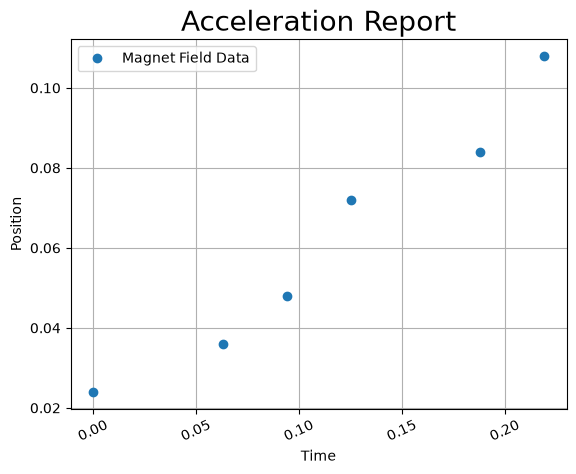

In [10]:
plt.plot(
    x,
    y,
    marker='o',
    linestyle = "none",
    label='Magnet Field Data'
)

plt.xticks(rotation=25)
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Acceleration Report', fontsize=20)
plt.grid()
plt.legend()
plt.show()

In [11]:
from scipy.optimize import curve_fit

def position_model(t, a, y0):
    return y0 + 0.5 * a * t**2

coefficients, covariance = curve_fit(
    position_model,
    x,
    y
)

a = coefficients[0]
y0 = coefficients[1]

x_fit = np.linspace(min(x), max(x), 200)
y_fit = position_model(x_fit, a, y0)

print(f"Acceleration = {a:.4f} m/s²")
print(f"Initial position = {y0:.4f} m/s²")

Acceleration = 3.2249 m/s²
Initial position = 0.0320 m/s²


## Final output

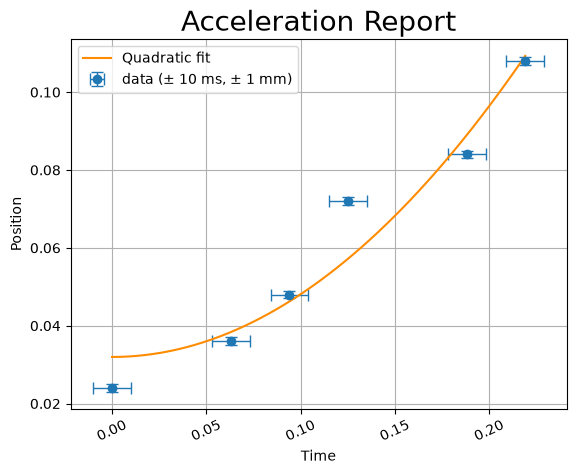

Acceleration = 3.2249 m/s²
Initial position = 0.0320 m


In [12]:
plt.errorbar(
    x,
    y,
    xerr=0.01,
    yerr=0.001,
    fmt='o',                 
    capsize=4,                      
    elinewidth=1,            
    label='data (± 10 ms, ± 1 mm)' #https://matplotlib.org/stable/gallery/statistics/errorbar.html
)

plt.plot(
    x_fit,
    y_fit,
    linestyle='-',
    color='darkorange',
    label='Quadratic fit'
)



plt.xticks(rotation=25)
plt.xlabel('Time')
plt.ylabel('Position')
plt.title('Acceleration Report', fontsize=20)
plt.grid()
plt.legend()
plt.show()

print(f"Acceleration = {a:.4f} m/s²")
print(f"Initial position = {y0:.4f} m")